In [1]:
import pandas as pd
import numpy as np
import os 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import xgboost as xgb
import time 

In [2]:
# --- Define Data Paths and Parameters for BEBE Bears Dataset ---

BASE_DIR = '/kaggle/input/datasets/sruthi0304/bebe-bears-2/formatted_pagano_bears/clip_data'

# Column layout (confirmed from dataset_metadata.yaml):
# Col 0: AccX  Col 1: AccY  Col 2: AccZ  (sensor features)
# Col 3: Wetdry  (NOT a sensor — drop this)
# Col 4: individual_id  (bear ID, NOT the label)
# Col 5: label  (behavior class 0-10)

SENSOR_COLUMNS = [0, 1, 2]       # Only 3 accelerometer axes
LABEL_COLUMN_INDEX = 5            # Column 5 = behavior label
INDIVIDUAL_ID_COLUMN = 4          # Column 4 = bear ID (used for splitting)
SAMPLING_RATE = 16                # Confirmed 16 Hz from metadata

# Label mapping (0=unknown, 1=dig, 2=eat, ..., 10=walk)
LABEL_NAMES = {
    1: 'dig', 2: 'eat', 3: 'groom', 4: 'head_shake',
    5: 'pounce', 6: 'rest', 7: 'roll', 8: 'run', 9: 'swim', 10: 'walk'
}

print("Configuration loaded:")
print(f"  Sensor columns : {SENSOR_COLUMNS}  (AccX, AccY, AccZ)")
print(f"  Label column   : {LABEL_COLUMN_INDEX}")
print(f"  Sampling rate  : {SAMPLING_RATE} Hz")
print(f"  Behavior classes: {len(LABEL_NAMES)} ({list(LABEL_NAMES.values())})")


Configuration loaded:
  Sensor columns : [0, 1, 2]  (AccX, AccY, AccZ)
  Label column   : 5
  Sampling rate  : 16 Hz
  Behavior classes: 10 (['dig', 'eat', 'groom', 'head_shake', 'pounce', 'rest', 'roll', 'run', 'swim', 'walk'])


In [3]:
# --- Merge All Individual CSVs into a Master DataFrame ---
import os
import pandas as pd

all_files = os.listdir(BASE_DIR)
csv_files = [f for f in all_files if f.endswith('.csv')]
csv_files = sorted(csv_files)[:25]
print(f"Total CSV files found: {len(csv_files)}")

all_dataframes = []
print(f"Starting merge of {len(csv_files)} clip files...")

for filename in csv_files:
    file_path = os.path.join(BASE_DIR, filename)
    df = pd.read_csv(file_path, header=None, sep=',')
    df['source_file'] = filename
    all_dataframes.append(df)

master_df = pd.concat(all_dataframes, ignore_index=True)
master_df = master_df[[0, 1, 2, 4, 5, 'source_file']].copy()
master_df.rename(columns={
    0: 'AccX',
    1: 'AccY',
    2: 'AccZ',
    4: 'individual_id',
    5: 'behavior_label',
}, inplace=True)

master_df['behavior_name'] = master_df['behavior_label'].map(LABEL_NAMES)

# ↓↓↓ ADD HERE — after renaming, before the prints ↓↓↓
# Remove 'unknown' label — not a real behavior, just unannotated data
master_df = master_df[master_df['behavior_label'] != 0].reset_index(drop=True)
print(f"After removing 'unknown': {len(master_df):,} rows remaining")

print("\n--- Master DataFrame Ready ---")
print(f"Total Rows       : {len(master_df):,}")
print(f"Columns          : {list(master_df.columns)}")
print(f"Behavior classes : {sorted(master_df['behavior_label'].unique())}")
print(f"Individual bears : {sorted(master_df['individual_id'].unique())}")
print(master_df.head()) 

Total CSV files found: 25
Starting merge of 25 clip files...
After removing 'unknown': 6,266,277 rows remaining

--- Master DataFrame Ready ---
Total Rows       : 6,266,277
Columns          : ['AccX', 'AccY', 'AccZ', 'individual_id', 'behavior_label', 'source_file', 'behavior_name']
Behavior classes : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
Individual bears : [np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
   AccX  AccY  AccZ  individual_id  behavior_label source_file behavior_name
0 -3.85 -1.80 -8.70            5.0             6.0  clip_0.csv          rest
1 -3.90 -1.85 -8.70            5.0             6.0  clip_0.csv          rest
2 -3.90 -1.85 -8.65            5.0             6.0  clip_0.csv          rest
3 -3.90 -1.95 -8.65            5.0             6.0  clip_0.csv          rest
4 -3.90 -1.90 -8.70            5.0             6.0  

BEHAVIOR LABEL DISTRIBUTION

Absolute Counts:
   1 (dig         ):     69,152
   2 (eat         ):    180,016
   3 (groom       ):     54,144
   4 (head_shake  ):     37,301
   5 (pounce      ):      5,312
   6 (rest        ):  4,701,328
   7 (roll        ):     59,072
   8 (run         ):     26,304
   9 (swim        ):     61,584
  10 (walk        ):  1,072,064

Percentage Distribution:
   1 (dig         ): 1.10%
   2 (eat         ): 2.87%
   3 (groom       ): 0.86%
   4 (head_shake  ): 0.60%
   5 (pounce      ): 0.08%
   6 (rest        ): 75.03%
   7 (roll        ): 0.94%
   8 (run         ): 0.42%
   9 (swim        ): 0.98%
  10 (walk        ): 17.11%


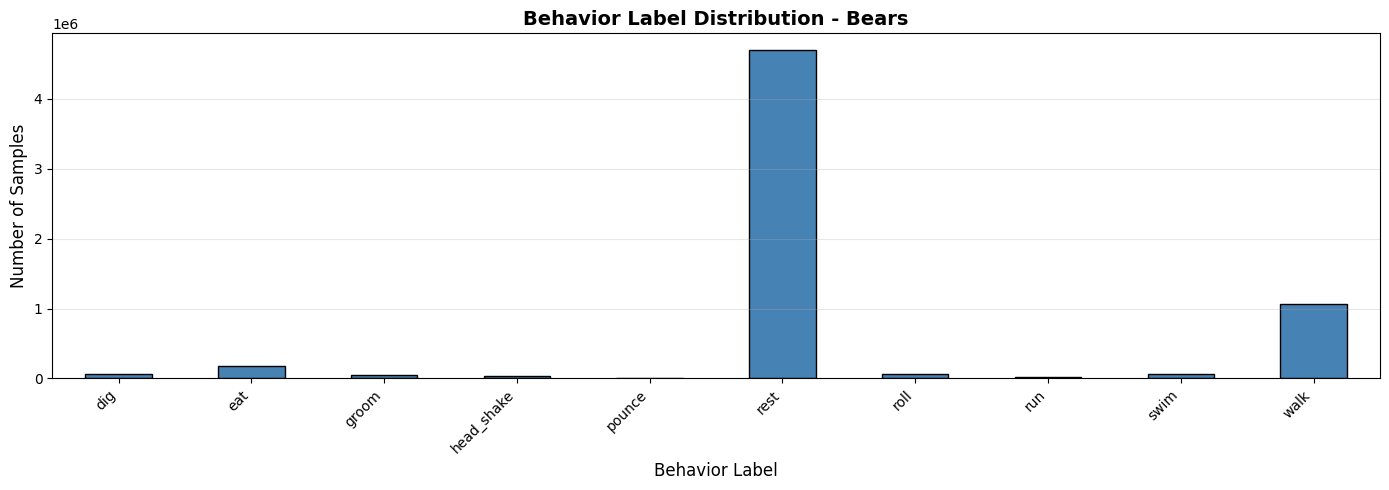

In [4]:
# --- Behavior Label Distribution ---
print("=" * 70)
print("BEHAVIOR LABEL DISTRIBUTION")
print("=" * 70)

label_counts = master_df['behavior_label'].value_counts().sort_index()
print("\nAbsolute Counts:")
for label, count in label_counts.items():
    name = LABEL_NAMES.get(int(label), 'unknown')
    print(f"  {int(label):2d} ({name:<12}): {count:>10,}")

print("\nPercentage Distribution:")
label_percentages = (label_counts / len(master_df) * 100).round(2)
for label, pct in label_percentages.items():
    name = LABEL_NAMES.get(int(label), 'unknown')
    print(f"  {int(label):2d} ({name:<12}): {pct:.2f}%")

# Visualize
import matplotlib.pyplot as plt
labels_sorted = label_counts.index.astype(int)
names = [LABEL_NAMES.get(l, str(l)) for l in labels_sorted]

plt.figure(figsize=(14, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Behavior Label Distribution - Bears', fontsize=14, fontweight='bold')
plt.xlabel('Behavior Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=range(len(names)), labels=names, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
# Convert labels to int
master_df['behavior_label'] = master_df['behavior_label'].astype(int)
print("Label dtype:", master_df['behavior_label'].dtype)
print("Sample rows:")
print(master_df[['AccX','AccY','AccZ','individual_id','behavior_label','behavior_name']].head())


Label dtype: int64
Sample rows:
   AccX  AccY  AccZ  individual_id  behavior_label behavior_name
0 -3.85 -1.80 -8.70            5.0               6          rest
1 -3.90 -1.85 -8.70            5.0               6          rest
2 -3.90 -1.85 -8.65            5.0               6          rest
3 -3.90 -1.95 -8.65            5.0               6          rest
4 -3.90 -1.90 -8.70            5.0               6          rest


In [6]:
def create_sliding_windows(df, window_size_sec=2, overlap_ratio=0.0,
                          purity_threshold=0.7):
    """
    Create sliding windows from bear accelerometer data.
    Bears have 3-axis accelerometer only (AccX, AccY, AccZ).
    Sampling rate: 16 Hz  →  2s window = 32 samples
    """
    window_samples = int(window_size_sec * SAMPLING_RATE)  # 2 * 16 = 32 samples
    step_size = int(window_samples * (1 - overlap_ratio))  # 50% overlap = 16 samples

    windows = []
    labels  = []
    source_files = []

    print(f"Window Configuration:")
    print(f"  Window size       : {window_size_sec}s = {window_samples} samples at {SAMPLING_RATE} Hz")
    print(f"  Step size         : {step_size} samples (50% stride)")
    print(f"  Purity threshold  : {purity_threshold*100:.0f}%")

    unique_files = df['source_file'].unique()
    num_files = len(unique_files)
    print(f"\nProcessing {num_files} clip files (bears)...\n")

    for file_idx, source_file in enumerate(unique_files):
        bear_data = df[df['source_file'] == source_file].reset_index(drop=True)

        # Extract only the 3 accelerometer columns
        sensor_data = bear_data[['AccX', 'AccY', 'AccZ']].values

        for i in range(0, len(bear_data) - window_samples + 1, step_size):
            window_sensor = sensor_data[i:i + window_samples]
            window_labels = bear_data['behavior_label'].iloc[i:i + window_samples]

            # Majority voting for label purity
            behavior_counts  = window_labels.value_counts()
            dominant_behavior = behavior_counts.idxmax()
            dominant_ratio   = behavior_counts.max() / len(window_labels)

            if dominant_ratio >= purity_threshold:
                windows.append(window_sensor)
                labels.append(dominant_behavior)
                source_files.append(source_file)

        if (file_idx + 1) % 10 == 0:
            print(f"  Processed {file_idx+1}/{num_files} files | Total windows: {len(windows):,}")

    X_raw = np.array(windows, dtype=np.float32)
    y     = np.array(labels,  dtype=np.int32)

    print(f"\n All {num_files} files processed")
    return X_raw, y, np.array(source_files)

# ── RUN ──
print("=" * 70)
print("CREATING SLIDING WINDOWS")
print("=" * 70)

X_raw, y, source_files = create_sliding_windows(
    master_df,
    window_size_sec=2,
    overlap_ratio=0.0,
    purity_threshold=0.7
)

print("\n" + "=" * 70)
print("WINDOWING COMPLETE")
print("=" * 70)
print(f"Total windows : {X_raw.shape[0]:,}")
print(f"Window shape  : {X_raw.shape}  ({X_raw.shape[1]} timesteps × {X_raw.shape[2]} axes)")
print(f"Memory usage  : {X_raw.nbytes / 1024**2:.2f} MB")


CREATING SLIDING WINDOWS
Window Configuration:
  Window size       : 2s = 32 samples at 16 Hz
  Step size         : 32 samples (50% stride)
  Purity threshold  : 70%

Processing 21 clip files (bears)...

  Processed 10/21 files | Total windows: 95,260
  Processed 20/21 files | Total windows: 187,464

 All 21 files processed

WINDOWING COMPLETE
Total windows : 194,025
Window shape  : (194025, 32, 3)  (32 timesteps × 3 axes)
Memory usage  : 71.05 MB



WINDOWED DATA - CLASS DISTRIBUTION
 Behavior  Count  Percentage
        6 146598       75.56
       10  33032       17.02
        2   5543        2.86
        1   2051        1.06
        9   1865        0.96
        7   1694        0.87
        3   1623        0.84
        4    753        0.39
        8    748        0.39
        5    118        0.06


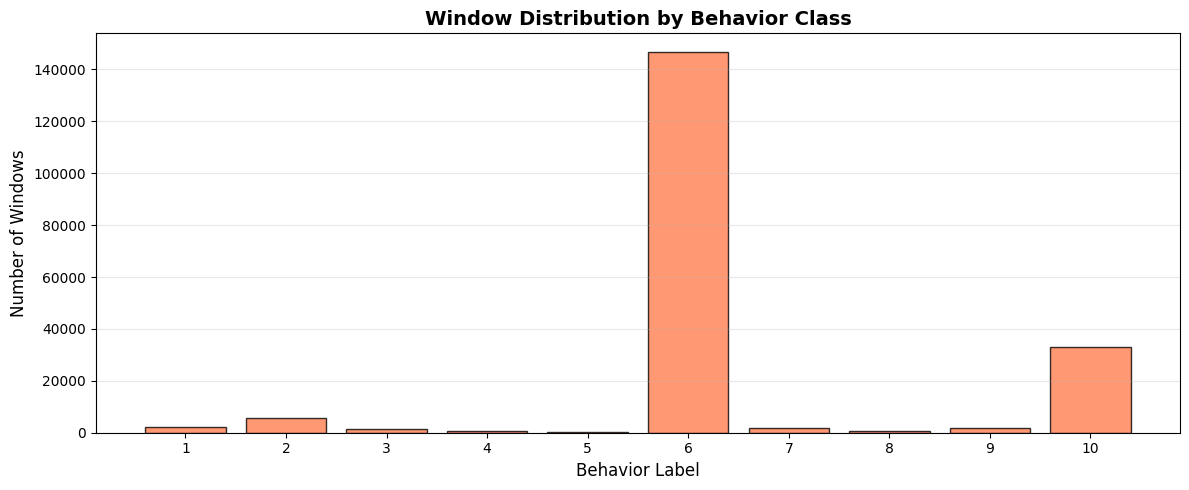

In [7]:
# Analyze windowed data distribution
print("\n" + "=" * 70)
print("WINDOWED DATA - CLASS DISTRIBUTION")
print("=" * 70)

unique_labels, label_counts = np.unique(y, return_counts=True)
window_distribution = pd.DataFrame({
    'Behavior': unique_labels.astype(int),
    'Count': label_counts,
    'Percentage': (label_counts / len(y) * 100).round(2)
}).sort_values('Count', ascending=False)

print(window_distribution.to_string(index=False))

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.bar(window_distribution['Behavior'], window_distribution['Count'], 
        color='coral', edgecolor='black', alpha=0.8)
plt.title('Window Distribution by Behavior Class', fontsize=14, fontweight='bold')
plt.xlabel('Behavior Label', fontsize=12)
plt.ylabel('Number of Windows', fontsize=12)
plt.xticks(window_distribution['Behavior'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Save raw windows for later use
np.save('/kaggle/working/X_raw_windows.npy', X_raw)
np.save('/kaggle/working/y_labels.npy', y)
np.save('/kaggle/working/source_files.npy', source_files)

print("\n Raw windows saved!")
print("  - X_raw_windows.npy")
print("  - y_labels.npy")
print("  - source_files.npy")


 Raw windows saved!
  - X_raw_windows.npy
  - y_labels.npy
  - source_files.npy


In [9]:
def extract_statistical_features(window):
    """
    Extract time-domain statistical features from a single window.
    Input : window of shape (32, 3) — 32 timesteps, 3 axes (AccX, AccY, AccZ)
    Output: dict of 35 features
    """
    features = {}

    for axis_idx, axis_name in enumerate(['x', 'y', 'z']):
        axis_data = window[:, axis_idx]
        features[f'{axis_name}_mean']   = np.mean(axis_data)
        features[f'{axis_name}_std']    = np.std(axis_data)
        features[f'{axis_name}_min']    = np.min(axis_data)
        features[f'{axis_name}_max']    = np.max(axis_data)
        features[f'{axis_name}_range']  = np.ptp(axis_data)
        features[f'{axis_name}_median'] = np.median(axis_data)
        features[f'{axis_name}_q25']    = np.percentile(axis_data, 25)
        features[f'{axis_name}_q75']    = np.percentile(axis_data, 75)
        features[f'{axis_name}_iqr']    = np.percentile(axis_data, 75) - np.percentile(axis_data, 25)

    # Magnitude (vector norm across 3 axes)
    magnitude = np.sqrt(np.sum(window**2, axis=1))
    features['magnitude_mean'] = np.mean(magnitude)
    features['magnitude_std']  = np.std(magnitude)
    features['magnitude_max']  = np.max(magnitude)
    features['magnitude_min']  = np.min(magnitude)

    # Signal Magnitude Area
    features['sma'] = np.sum(np.abs(window)) / len(window)

    # Cross-axis correlations
    features['corr_xy'] = np.corrcoef(window[:, 0], window[:, 1])[0, 1]
    features['corr_xz'] = np.corrcoef(window[:, 0], window[:, 2])[0, 1]
    features['corr_yz'] = np.corrcoef(window[:, 1], window[:, 2])[0, 1]

    return features

# ── EXTRACT ──
print("=" * 70)
print("EXTRACTING FEATURES FOR XGBOOST")
print("=" * 70)
print(f"Processing {X_raw.shape[0]:,} windows (32 timesteps × 3 axes)...")

from tqdm import tqdm
feature_list = [extract_statistical_features(w) for w in tqdm(X_raw, desc="Extracting")]

X_features = pd.DataFrame(feature_list)

print("\n" + "=" * 70)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 70)
print(f"Feature matrix : {X_features.shape}  ({X_features.shape[1]} features per window)")
print(f"Memory usage   : {X_features.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nFeature names  : {X_features.columns.tolist()}")


EXTRACTING FEATURES FOR XGBOOST
Processing 194,025 windows (32 timesteps × 3 axes)...


Extracting:   0%|          | 63/194025 [00:00<05:09, 626.39it/s]/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Extracting: 100%|██████████| 194025/194025 [05:14<00:00, 616.38it/s]



FEATURE EXTRACTION COMPLETE
Feature matrix : (194025, 35)  (35 features per window)
Memory usage   : 28.13 MB

Feature names  : ['x_mean', 'x_std', 'x_min', 'x_max', 'x_range', 'x_median', 'x_q25', 'x_q75', 'x_iqr', 'y_mean', 'y_std', 'y_min', 'y_max', 'y_range', 'y_median', 'y_q25', 'y_q75', 'y_iqr', 'z_mean', 'z_std', 'z_min', 'z_max', 'z_range', 'z_median', 'z_q25', 'z_q75', 'z_iqr', 'magnitude_mean', 'magnitude_std', 'magnitude_max', 'magnitude_min', 'sma', 'corr_xy', 'corr_xz', 'corr_yz']


In [10]:
# Save everything for later use
print("\n" + "=" * 70)
print("SAVING PREPROCESSED DATA")
print("=" * 70)

# Save features for XGBoost
X_features.to_csv('/kaggle/working/features_xgboost.csv', index=False)
pd.DataFrame({'behavior_label': y}).to_csv('/kaggle/working/labels.csv', index=False)

# Save raw windows for CNN-LSTM (already saved earlier)
# np.save('/kaggle/working/X_raw_windows.npy', X_raw)
# np.save('/kaggle/working/y_labels.npy', y)
# np.save('/kaggle/working/source_files.npy', source_files)

print(" All data saved")
print("\n Files created:")
print("  1. features_xgboost.csv - Feature matrix for XGBoost")
print("  2. labels.csv - Behavior labels")
print("  3. X_raw_windows.npy - Raw windows for CNN-LSTM")
print("  4. y_labels.npy - Labels (numpy format)")
print("  5. source_files.npy - Source file mapping")


SAVING PREPROCESSED DATA
 All data saved

 Files created:
  1. features_xgboost.csv - Feature matrix for XGBoost
  2. labels.csv - Behavior labels
  3. X_raw_windows.npy - Raw windows for CNN-LSTM
  4. y_labels.npy - Labels (numpy format)
  5. source_files.npy - Source file mapping


In [11]:
#Quick statistical summary
print("\n" + "=" * 70)
print("FEATURE STATISTICS SUMMARY")
print("=" * 70)

print("\n Feature statistics:")
print(X_features.describe().T[['mean', 'std', 'min', 'max']])

# Check for any NaN or inf values
print(f"\n NaN values: {X_features.isna().sum().sum()}")
print(f" Inf values: {np.isinf(X_features.values).sum()}")

# If there are NaN/Inf, handle them
if X_features.isna().sum().sum() > 0 or np.isinf(X_features.values).sum() > 0:
    print("\n Cleaning data...")
    X_features = X_features.replace([np.inf, -np.inf], np.nan)
    X_features = X_features.fillna(X_features.median())
    print(" Data cleaned")


FEATURE STATISTICS SUMMARY

 Feature statistics:
                     mean       std        min        max
x_mean          -6.421250  3.464957 -12.331250   9.645313
x_std            0.817076  1.651968   0.000000  19.102102
x_min           -8.111686  5.437879 -25.000000   8.500001
x_max           -4.772939  4.088133 -10.400000  26.200001
x_range          3.338747  6.491902   0.000000  50.950001
x_median        -6.388860  3.454447 -15.150000  10.025002
x_q25           -6.980244  4.017525 -25.000000   8.900001
x_q75           -5.872012  3.320544 -10.400000  22.050001
x_iqr            1.108232  2.476757   0.000000  39.925003
y_mean          -0.446735  2.905172 -11.095312  10.940626
y_std            0.658742  1.227681   0.000000  16.103661
y_min           -1.906236  4.071458 -25.000000  10.250000
y_max            0.965281  4.038373  -9.099999  24.000002
y_range          2.871516  5.505407   0.000000  49.000000
y_median        -0.445085  2.913930 -10.800000  11.100000
y_q25           -0.849

In [12]:
print("=" * 70)
print("TRAIN-TEST SPLIT  (by individual bear — no data leakage)")
print("=" * 70)

# Bear IDs: 5, 6, 7, 8, 9  (5 individuals)
# Use the individual_id from master_df aligned to source_files
# Build a map: source_file -> individual_id
file_to_individual = (
    master_df.groupby('source_file')['individual_id']
    .first()
    .to_dict()
)

# Map each window's source_file to its bear's individual_id
individual_per_window = np.array([
    file_to_individual[sf] for sf in source_files
])

unique_individuals = np.unique(individual_per_window)
print(f"Total individual bears: {len(unique_individuals)}  (IDs: {unique_individuals})")

# 80/20 split by individual (4 bears train, 1 bear test)
train_individuals, test_individuals = train_test_split(
    unique_individuals,
    test_size=0.2,
    random_state=42
)

print(f"Train bears: {train_individuals}")
print(f"Test  bears: {test_individuals}")

train_mask = np.isin(individual_per_window, train_individuals)
test_mask  = np.isin(individual_per_window, test_individuals)

# Feature split (XGBoost)
X_train_features = X_features[train_mask].reset_index(drop=True)
X_test_features  = X_features[test_mask].reset_index(drop=True)
y_train = y[train_mask]
y_test  = y[test_mask]

# Raw window split (CNN-LSTM)
X_train_raw = X_raw[train_mask]
X_test_raw  = X_raw[test_mask]

print(f"\nTrain windows : {len(X_train_features):,}")
print(f"Test  windows : {len(X_test_features):,}")

print("\nTrain class distribution:")
for label, count in pd.Series(y_train).value_counts().sort_index().items():
    print(f"  {int(label):2d} ({LABEL_NAMES.get(int(label),'?'):<12}): {count:,}")

print("\nTest class distribution:")
for label, count in pd.Series(y_test).value_counts().sort_index().items():
    print(f"  {int(label):2d} ({LABEL_NAMES.get(int(label),'?'):<12}): {count:,}")


TRAIN-TEST SPLIT  (by individual bear — no data leakage)
Total individual bears: 4  (IDs: [5. 6. 7. 8.])
Train bears: [8. 5. 7.]
Test  bears: [6.]

Train windows : 157,190
Test  windows : 36,835

Train class distribution:
   1 (dig         ): 1,988
   2 (eat         ): 4,671
   3 (groom       ): 1,270
   4 (head_shake  ): 748
   5 (pounce      ): 116
   6 (rest        ): 115,948
   7 (roll        ): 1,566
   8 (run         ): 460
   9 (swim        ): 1,865
  10 (walk        ): 28,558

Test class distribution:
   1 (dig         ): 63
   2 (eat         ): 872
   3 (groom       ): 353
   4 (head_shake  ): 5
   5 (pounce      ): 2
   6 (rest        ): 30,650
   7 (roll        ): 128
   8 (run         ): 288
  10 (walk        ): 4,474


In [13]:
print("\n" + "=" * 70)
print("SAVING TRAIN-TEST SPLITS")
print("=" * 70)

# Save XGBoost data (features)
X_train_features.to_csv('/kaggle/working/X_train_features.csv', index=False)
X_test_features.to_csv('/kaggle/working/X_test_features.csv', index=False)
pd.DataFrame({'behavior_label': y_train}).to_csv('/kaggle/working/y_train.csv', index=False)
pd.DataFrame({'behavior_label': y_test}).to_csv('/kaggle/working/y_test.csv', index=False)

# Save CNN-LSTM data (raw windows)
np.save('/kaggle/working/X_train_raw.npy', X_train_raw)
np.save('/kaggle/working/X_test_raw.npy', X_test_raw)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/y_test.npy', y_test)

# Save file splits for reference
np.save('/kaggle/working/train_files.npy', train_individuals)
np.save('/kaggle/working/test_files.npy', test_individuals)

print("\n All splits saved")
print("\n Files for XGBoost:")
print("  - X_train_features.csv")
print("  - X_test_features.csv")
print("  - y_train.csv")
print("  - y_test.csv")

print("\n Files for CNN-LSTM:")
print("  - X_train_raw.npy")
print("  - X_test_raw.npy")
print("  - y_train.npy")
print("  - y_test.npy")

print("\n Reference files:")
print("  - train_files.npy (which bears are in train set)")
print("  - test_files.npy (which bears are in test set)")


SAVING TRAIN-TEST SPLITS

 All splits saved

 Files for XGBoost:
  - X_train_features.csv
  - X_test_features.csv
  - y_train.csv
  - y_test.csv

 Files for CNN-LSTM:
  - X_train_raw.npy
  - X_test_raw.npy
  - y_train.npy
  - y_test.npy

 Reference files:
  - train_files.npy (which bears are in train set)
  - test_files.npy (which bears are in test set)


In [14]:
NUM_CLASSES = len(LABEL_NAMES)

summary = f"""
Dataset: BEBE Bears (Pagano) — Behavioral Classification
=========================================================

ANIMAL  : Polar Bears (wild) — IMU collar data
SOURCE  : BEBE Dataset — Pagano et al.

RAW DATA:
  • Total clips       : {master_df['source_file'].nunique()}
  • Total samples     : {len(master_df):,}
  • Individual bears  : {master_df['individual_id'].nunique()} (IDs: {sorted(master_df['individual_id'].unique())})
  • Sampling rate     : {SAMPLING_RATE} Hz (confirmed from metadata)
  • Sensor channels   : 3 (AccX, AccY, AccZ — accelerometer only)
  • Behavior classes  : {NUM_CLASSES} ({list(LABEL_NAMES.values())})

WINDOWING:
  • Window size       : 2 seconds = {int(2*SAMPLING_RATE)} samples at {SAMPLING_RATE} Hz
  • Overlap           : 50% (stride = {int(SAMPLING_RATE)} samples)
  • Purity threshold  : 70%
  • Total windows     : {X_raw.shape[0]:,}

FEATURE ENGINEERING (35 features per window):
  • Per-axis stats    : 9 × 3 axes = 27  (mean, std, min, max, range, median, q25, q75, iqr)
  • Magnitude stats   : 4               (mean, std, max, min)
  • SMA               : 1
  • Cross-axis corrs  : 3               (xy, xz, yz)

TRAIN-TEST SPLIT (by individual bear — no data leakage):
  • Train bears : {train_individuals}  ({len(X_train_features):,} windows)
  • Test  bears : {test_individuals}  ({len(X_test_features):,} windows)

READY FOR MODEL TRAINING ✓
"""
print(summary)

with open('/kaggle/working/preprocessing_summary.txt', 'w') as f:
    f.write(summary)
print("Summary saved.")



Dataset: BEBE Bears (Pagano) — Behavioral Classification

ANIMAL  : Polar Bears (wild) — IMU collar data
SOURCE  : BEBE Dataset — Pagano et al.

RAW DATA:
  • Total clips       : 21
  • Total samples     : 6,266,277
  • Individual bears  : 4 (IDs: [np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)])
  • Sampling rate     : 16 Hz (confirmed from metadata)
  • Sensor channels   : 3 (AccX, AccY, AccZ — accelerometer only)
  • Behavior classes  : 10 (['dig', 'eat', 'groom', 'head_shake', 'pounce', 'rest', 'roll', 'run', 'swim', 'walk'])

WINDOWING:
  • Window size       : 2 seconds = 32 samples at 16 Hz
  • Overlap           : 50% (stride = 16 samples)
  • Purity threshold  : 70%
  • Total windows     : 194,025

FEATURE ENGINEERING (35 features per window):
  • Per-axis stats    : 9 × 3 axes = 27  (mean, std, min, max, range, median, q25, q75, iqr)
  • Magnitude stats   : 4               (mean, std, max, min)
  • SMA               : 1
  • Cross-axis corrs  : 3            

In [15]:
files_to_check = [
    'X_train_features.csv',
    'X_test_features.csv', 
    'y_train.csv',
    'y_test.csv',
    'X_train_raw.npy',
    'X_test_raw.npy',
    'y_train.npy',
    'y_test.npy',
    'train_files.npy',
    'test_files.npy',
    'preprocessing_summary.txt'
]

print("\n Checking saved files:")
all_exist = True
for filename in files_to_check:
    filepath = f'/kaggle/working/{filename}'
    exists = os.path.exists(filepath)
    status = "Yes" if exists else "No"
    size = os.path.getsize(filepath) / 1024**2 if exists else 0
    print(f"{status} {filename:<30} ({size:.2f} MB)")
    if not exists:
        all_exist = False

if all_exist:
    print("\n" + "=" * 70)
    print(" WEEK 1 PREPROCESSING COMPLETE!")
    print("=" * 70)
    print("\n All files saved successfully!")
    print(" Ready to start Week 2: Model Training")
    print("\nNext steps:")
    print("  1. Train XGBoost baseline model")
    print("  2. Build and train CNN-LSTM model")
    print("  3. Compare performance metrics")
else:
    print("\n Some files are missing! Please re-run the save commands.")


 Checking saved files:
Yes X_train_features.csv           (55.33 MB)
Yes X_test_features.csv            (12.96 MB)
Yes y_train.csv                    (0.33 MB)
Yes y_test.csv                     (0.07 MB)
Yes X_train_raw.npy                (57.56 MB)
Yes X_test_raw.npy                 (13.49 MB)
Yes y_train.npy                    (0.60 MB)
Yes y_test.npy                     (0.14 MB)
Yes train_files.npy                (0.00 MB)
Yes test_files.npy                 (0.00 MB)
Yes preprocessing_summary.txt      (0.00 MB)

 WEEK 1 PREPROCESSING COMPLETE!

 All files saved successfully!
 Ready to start Week 2: Model Training

Next steps:
  1. Train XGBoost baseline model
  2. Build and train CNN-LSTM model
  3. Compare performance metrics


PREPROCESSING COMPLETE

XGBOOST

In [16]:
# Set random seed for reproducibility
np.random.seed(42)

print("=" * 70)
print("MODEL TRAINING - XGBoost Baseline")
print("=" * 70)

# ========== LOAD PREPROCESSED DATA ==========
# Update this path to match your uploaded dataset name
DATA_PATH = '/kaggle/input/datasets/sruthi0304/bebe-bears-preprocessed-1'  # ← UPDATE if needed

print("\n Loading preprocessed data...")

# Load XGBoost features
X_train = pd.read_csv(f'{DATA_PATH}/X_train_features.csv')
X_test = pd.read_csv(f'{DATA_PATH}/X_test_features.csv')
y_train = pd.read_csv(f'{DATA_PATH}/y_train.csv')['behavior_label'].values
y_test = pd.read_csv(f'{DATA_PATH}/y_test.csv')['behavior_label'].values

print("\n Data loaded")
print(f"\n Training Set: {X_train.shape[0]:,} windows, {X_train.shape[1]} features")
print(f" Test Set: {X_test.shape[0]:,} windows, {X_test.shape[1]} features")
print(f" Unique behaviors (bear behaviors): {len(np.unique(y_train))}")

# Check class distribution
print("\n Training set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Behavior {int(label)}: {count:,} ({count/len(y_train)*100:.2f}%)")

MODEL TRAINING - XGBoost Baseline

 Loading preprocessed data...

 Data loaded

 Training Set: 157,190 windows, 35 features
 Test Set: 36,835 windows, 35 features
 Unique behaviors (bear behaviors): 10

 Training set class distribution:
  Behavior 1: 1,988 (1.26%)
  Behavior 2: 4,671 (2.97%)
  Behavior 3: 1,270 (0.81%)
  Behavior 4: 748 (0.48%)
  Behavior 5: 116 (0.07%)
  Behavior 6: 115,948 (73.76%)
  Behavior 7: 1,566 (1.00%)
  Behavior 8: 460 (0.29%)
  Behavior 9: 1,865 (1.19%)
  Behavior 10: 28,558 (18.17%)


In [17]:
print("\n" + "=" * 70)
print("TRAINING XGBOOST MODEL")
print("=" * 70)

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Remap labels to 0-indexed for XGBoost (labels are 1-10, need 0-9)
le_xgb = LabelEncoder()
y_train_enc = le_xgb.fit_transform(y_train)
y_test_enc  = le_xgb.transform(y_test)

sample_weights = compute_sample_weight('balanced', y_train_enc)

print("\n XGBoost Configuration:")
print("  - Objective: Multi-class classification (softmax)")
print("  - Max depth: 6")
print("  - Learning rate: 0.1")
print("  - Estimators: 100")
print(f"  - Num classes: {len(np.unique(y_train_enc))} (auto-detected from bears data)")
print("  - Class weights: Balanced (to handle imbalance)")

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train_enc)),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

print("\n Training started...")
start_time = time.time()

xgb_model.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test_enc)],
    verbose=10
)

training_time = time.time() - start_time
print(f"\n Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


TRAINING XGBOOST MODEL

 XGBoost Configuration:
  - Objective: Multi-class classification (softmax)
  - Max depth: 6
  - Learning rate: 0.1
  - Estimators: 100
  - Num classes: 10 (auto-detected from bears data)
  - Class weights: Balanced (to handle imbalance)

 Training started...
[0]	validation_0-mlogloss:1.86880
[10]	validation_0-mlogloss:0.65414
[20]	validation_0-mlogloss:0.34677
[30]	validation_0-mlogloss:0.23542
[40]	validation_0-mlogloss:0.18872
[50]	validation_0-mlogloss:0.16708
[60]	validation_0-mlogloss:0.15504
[70]	validation_0-mlogloss:0.15047
[80]	validation_0-mlogloss:0.14467
[90]	validation_0-mlogloss:0.14186
[99]	validation_0-mlogloss:0.13954

 Training completed in 13.63 seconds (0.23 minutes)



CLASS IMBALANCE VERIFICATION
 Behavior  Sample Count  Sample Weight  Total Influence
        1          1988       7.906942          15719.0
        2          4671       3.365232          15719.0
        3          1270      12.377165          15719.0
        4           748      21.014706          15719.0
        5           116     135.508621          15719.0
        6        115948       0.135569          15719.0
        7          1566      10.037676          15719.0
        8           460      34.171739          15719.0
        9          1865       8.428418          15719.0
       10         28558       0.550424          15719.0


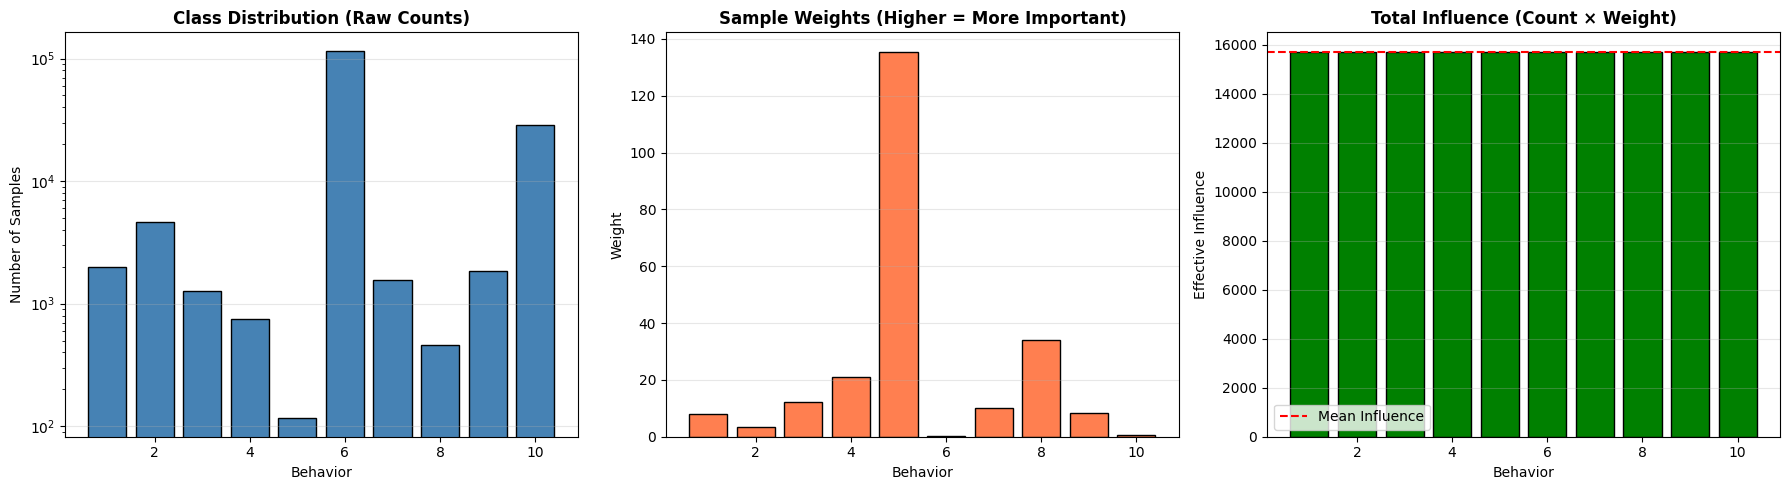


 If 'Total Influence' bars are roughly equal → Imbalance is handled correctly!


In [18]:
print("\n" + "=" * 70)
print("CLASS IMBALANCE VERIFICATION")
print("=" * 70)

present_labels = sorted(np.unique(y_train))
num_classes = len(present_labels)

weight_by_class = {}
for behavior in present_labels:
    class_mask = y_train == behavior
    if class_mask.sum() > 0:
        weight_by_class[behavior] = sample_weights[class_mask][0]
    else:
        weight_by_class[behavior] = 0

weight_df = pd.DataFrame({
    'Behavior': present_labels,
    'Sample Count': [np.sum(y_train == i) for i in present_labels],
    'Sample Weight': [weight_by_class[i] for i in present_labels],
    'Total Influence': [np.sum(y_train == i) * weight_by_class[i] for i in present_labels]
})

print(weight_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(weight_df['Behavior'], weight_df['Sample Count'], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution (Raw Counts)', fontweight='bold')
axes[0].set_xlabel('Behavior')
axes[0].set_ylabel('Number of Samples')
axes[0].set_yscale('log')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(weight_df['Behavior'], weight_df['Sample Weight'], color='coral', edgecolor='black')
axes[1].set_title('Sample Weights (Higher = More Important)', fontweight='bold')
axes[1].set_xlabel('Behavior')
axes[1].set_ylabel('Weight')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(weight_df['Behavior'], weight_df['Total Influence'], color='green', edgecolor='black')
axes[2].set_title('Total Influence (Count × Weight)', fontweight='bold')
axes[2].set_xlabel('Behavior')
axes[2].set_ylabel('Effective Influence')
axes[2].axhline(y=weight_df['Total Influence'].mean(), color='red',
                linestyle='--', label='Mean Influence')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_imbalance_handling.png', dpi=300)
plt.show()

print("\n If 'Total Influence' bars are roughly equal → Imbalance is handled correctly!")

In [19]:
print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

print("\n Making predictions...")
# Predict in encoded space then decode back to original labels (1-10)
y_train_pred = le_xgb.inverse_transform(xgb_model.predict(X_train))
y_test_pred  = le_xgb.inverse_transform(xgb_model.predict(X_test))

train_accuracy    = accuracy_score(y_train, y_train_pred)
test_accuracy     = accuracy_score(y_test,  y_test_pred)
train_f1_macro    = f1_score(y_train, y_train_pred, average='macro')
test_f1_macro     = f1_score(y_test,  y_test_pred,  average='macro')
train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
test_f1_weighted  = f1_score(y_test,  y_test_pred,  average='weighted')

print("\n PERFORMANCE METRICS:")
print("=" * 70)
print(f"{'Metric':<25} {'Train':<15} {'Test':<15}")
print("-" * 70)
print(f"{'Accuracy':<25} {train_accuracy:.4f} ({train_accuracy*100:.2f}%)  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'F1-Score (Macro)':<25} {train_f1_macro:.4f}          {test_f1_macro:.4f}")
print(f"{'F1-Score (Weighted)':<25} {train_f1_weighted:.4f}          {test_f1_weighted:.4f}")
print(f"{'Precision (Macro)':<25} {precision_score(y_train, y_train_pred, average='macro'):.4f}          {precision_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"{'Recall (Macro)':<25} {recall_score(y_train, y_train_pred, average='macro'):.4f}          {recall_score(y_test, y_test_pred, average='macro'):.4f}")
print("=" * 70)

print("\n DETAILED CLASSIFICATION REPORT (Test Set):")
print("=" * 70)
present_labels = sorted(np.unique(y_test))
target_names   = [LABEL_NAMES.get(l, str(l)) for l in present_labels]
print(classification_report(y_test, y_test_pred,
                             labels=present_labels,
                             target_names=target_names,
                             digits=4))


MODEL EVALUATION

 Making predictions...

 PERFORMANCE METRICS:
Metric                    Train           Test           
----------------------------------------------------------------------
Accuracy                  0.9588 (95.88%)  0.9590 (95.90%)
F1-Score (Macro)          0.8102          0.4852
F1-Score (Weighted)       0.9634          0.9659
Precision (Macro)         0.7349          0.4679
Recall (Macro)            0.9427          0.5609

 DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

         dig     0.0703    0.4127    0.1201        63
         eat     0.6402    0.6101    0.6248       872
       groom     0.3248    0.2890    0.3058       353
  head_shake     0.2857    0.8000    0.4211         5
      pounce     0.0000    0.0000    0.0000         2
        rest     0.9962    0.9833    0.9897     30650
        roll     0.5000    0.8281    0.6235       128
         run     0.8921    0.7465    0.8129       288
        walk     0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



CONFUSION MATRIX


/tmp/ipykernel_55/1073446301.py:6: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


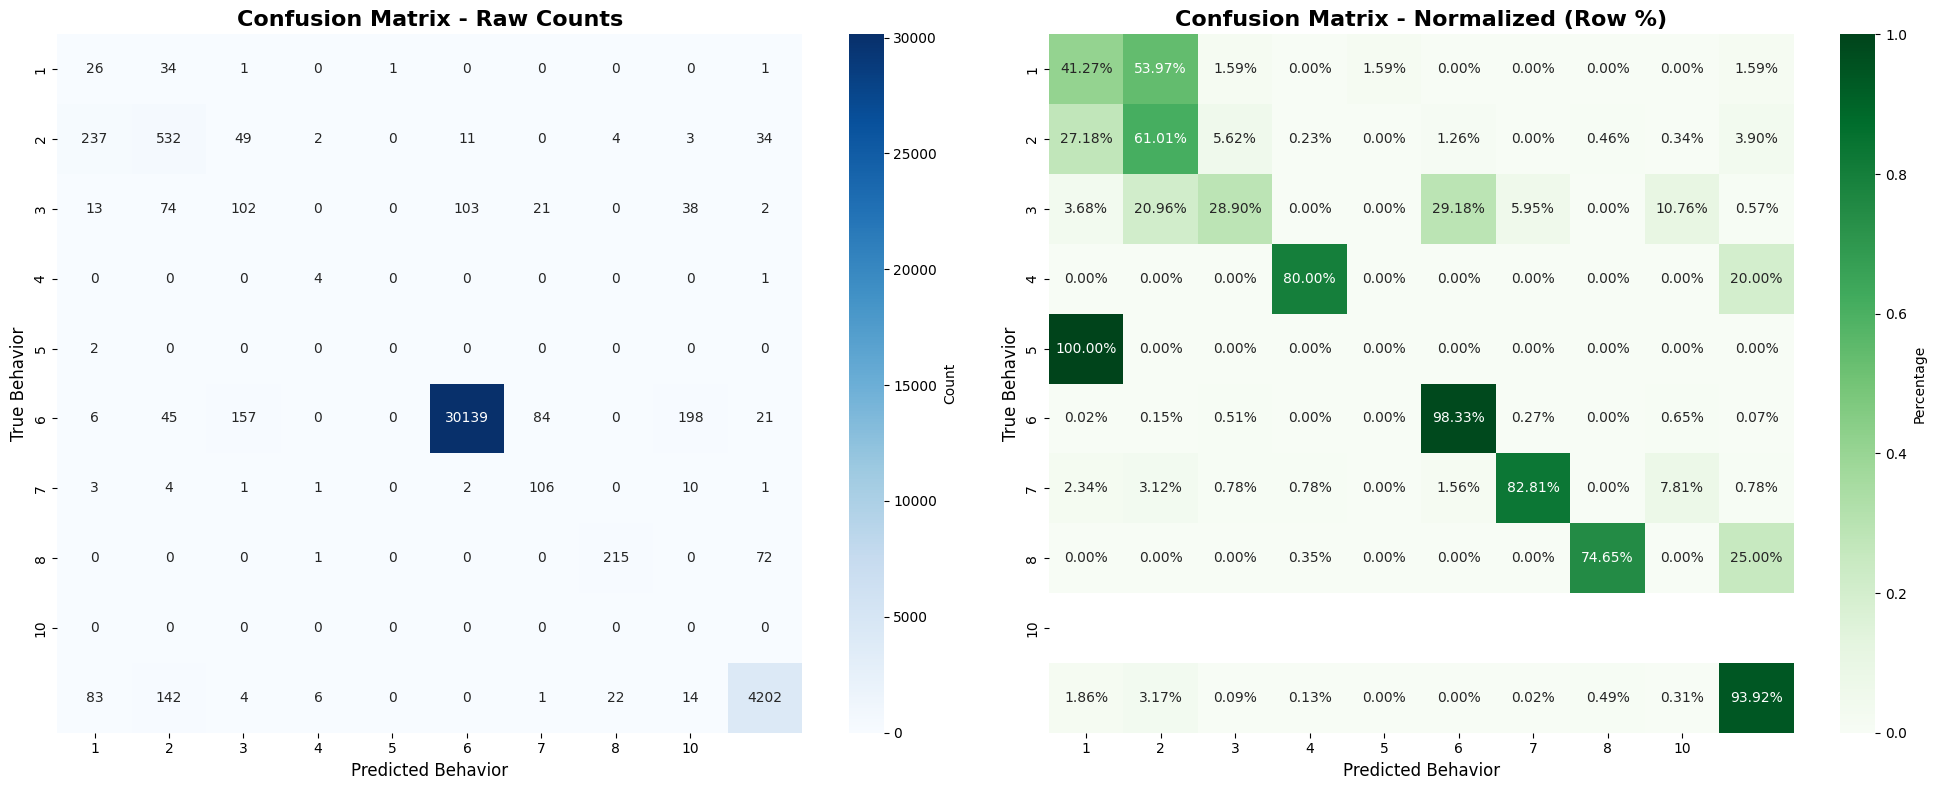


 Confusion matrix saved as: xgboost_confusion_matrix.png


In [20]:
print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(y_test, y_test_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

present_labels = sorted(np.unique(y_test))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=present_labels, yticklabels=present_labels,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Behavior', fontsize=12)
axes[0].set_ylabel('True Behavior', fontsize=12)

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=present_labels, yticklabels=present_labels,
            cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix - Normalized (Row %)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Predicted Behavior', fontsize=12)
axes[1].set_ylabel('True Behavior', fontsize=12)

plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Confusion matrix saved as: xgboost_confusion_matrix.png")


FEATURE IMPORTANCE ANALYSIS

 Top 15 Most Important Features:
       feature  importance
 magnitude_std    0.100044
         x_q25    0.075025
       z_range    0.067508
         y_min    0.063294
        x_mean    0.062509
         z_std    0.058549
        y_mean    0.046697
         y_max    0.045433
         y_q75    0.034666
       x_range    0.032158
      y_median    0.031795
         x_std    0.026004
         y_std    0.023615
       corr_xy    0.022632
magnitude_mean    0.022292


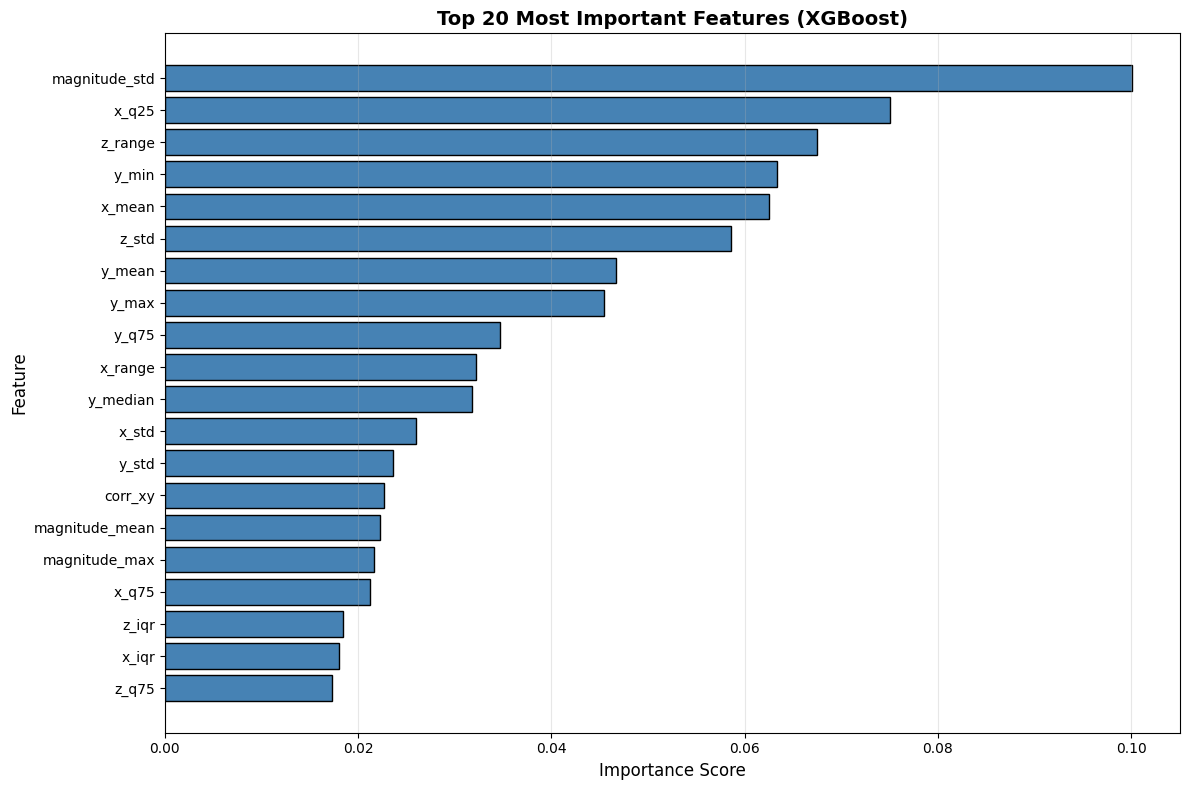


 Feature importance plot saved as: xgboost_feature_importance.png


In [21]:
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Visualize top 20 features
plt.figure(figsize=(12, 8))
top_20 = feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Feature importance plot saved as: xgboost_feature_importance.png")


PER-CLASS PERFORMANCE ANALYSIS

 Per-Behavior Performance:
 Behavior  Samples  Precision   Recall  F1-Score
        1       63   0.070270 0.412698  0.120092
        2      872   0.640193 0.610092  0.624780
        3      353   0.324841 0.288952  0.305847
        4        5   0.285714 0.800000  0.421053
        5        2   0.000000 0.000000  0.000000
        6    30650   0.996166 0.983328  0.989705
        7      128   0.500000 0.828125  0.623529
        8      288   0.892116 0.746528  0.812854
       10     4474   0.969543 0.939204  0.954133


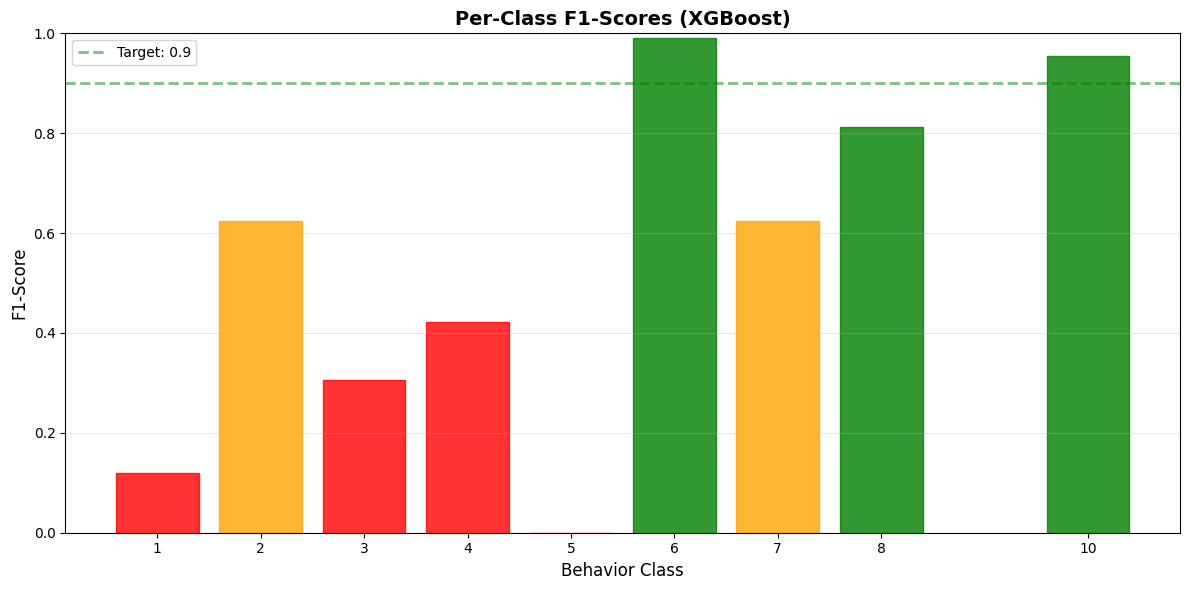


 Per-class performance plot saved as: xgboost_per_class_f1.png


In [22]:
print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 70)

present_labels = sorted(np.unique(y_test))

per_class_f1        = f1_score(y_test, y_test_pred, average=None, labels=present_labels)
per_class_precision = precision_score(y_test, y_test_pred, average=None, labels=present_labels)
per_class_recall    = recall_score(y_test, y_test_pred, average=None, labels=present_labels)

class_counts = pd.Series(y_test).value_counts().sort_index().reindex(present_labels, fill_value=0)

performance_df = pd.DataFrame({
    'Behavior': present_labels,
    'Samples': class_counts.values,
    'Precision': per_class_precision,
    'Recall': per_class_recall,
    'F1-Score': per_class_f1
})

print("\n Per-Behavior Performance:")
print(performance_df.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.bar(performance_df['Behavior'], performance_df['F1-Score'],
               color='coral', edgecolor='black', alpha=0.8)

for i, bar in enumerate(bars):
    f1 = performance_df.iloc[i]['F1-Score']
    if f1 >= 0.8:
        bar.set_color('green')
    elif f1 >= 0.6:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.axhline(y=0.9, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 0.9')
plt.xlabel('Behavior Class', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Per-Class F1-Scores (XGBoost)', fontsize=14, fontweight='bold')
plt.xticks(present_labels)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Per-class performance plot saved as: xgboost_per_class_f1.png")

In [23]:
print("\n" + "=" * 70)
print("SAVING MODEL")
print("=" * 70)

import json
import pickle

xgb_model.save_model('xgboost_model.json')
print(" Model saved as: xgboost_model.json")

# Save label encoder — needed to decode predictions in Cells 28
with open('xgb_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_xgb, f)
print(" Label encoder saved as: xgb_label_encoder.pkl")

# Save decoded predictions (original labels 1-10) — needed by Cell 28
np.save('xgboost_y_test_pred.npy', y_test_pred)
print(" Predictions saved as: xgboost_y_test_pred.npy")

summary = {
    'model': 'XGBoost',
    'training_time_seconds': training_time,
    'test_accuracy': test_accuracy,
    'test_f1_macro': test_f1_macro,
    'test_f1_weighted': test_f1_weighted,
    'num_features': X_train.shape[1],
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

with open('xgboost_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(" Performance summary saved as: xgboost_summary.json")
print("\n" + "=" * 70)
print(" XGBOOST TRAINING COMPLETE")
print("=" * 70)


SAVING MODEL
 Model saved as: xgboost_model.json
 Label encoder saved as: xgb_label_encoder.pkl
 Predictions saved as: xgboost_y_test_pred.npy
 Performance summary saved as: xgboost_summary.json

 XGBOOST TRAINING COMPLETE


CNN-LSTM

2026-03-16 14:07:34.791637: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773670055.001790      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773670055.062673      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773670055.563328      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773670055.563355      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773670055.563358      55 computation_placer.cc:177] computation placer alr

CNN-LSTM OPTIMIZED MODEL (V2) - WITH ALL FIXES

 Loading preprocessed data...

 Data loaded!
   Training : 157,190 windows
   Test     : 36,835 windows
   Window shape: (32 timesteps, 3 axes)

 Remapping labels to consecutive integers...
   Original label values : [ 1  2  3  4  5  6  7  8  9 10]
   Remapped to           : 0 – 9
   Class names           : ['dig', 'eat', 'groom', 'head_shake', 'pounce', 'rest', 'roll', 'run', 'swim', 'walk']

 Computing class weights for imbalanced data...

 Class weights:
  0 (dig         ): weight=7.907  (1,988 samples)
  1 (eat         ): weight=3.365  (4,671 samples)
  2 (groom       ): weight=12.377  (1,270 samples)
  3 (head_shake  ): weight=21.015  (748 samples)
  4 (pounce      ): weight=135.509  (116 samples)
  5 (rest        ): weight=0.136  (115,948 samples)
  6 (roll        ): weight=10.038  (1,566 samples)
  7 (run         ): weight=34.172  (460 samples)
  8 (swim        ): weight=8.428  (1,865 samples)
  9 (walk        ): weight=0.550  (28,

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773670081.226247      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773670081.231951      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



 Model Architecture Summary:


Model: "Enhanced_CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1a (Conv1D)              │ (None, 32, 128)        │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1a (BatchNormalization)      │ (None, 32, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1b (Conv1D)              │ (None, 32, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1b (BatchNormalization)      │ (None, 32, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling1D)           │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2a (Conv1D)              │ (None, 16, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2a (BatchNormalization)      │ (None, 16, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2b (Conv1D)              │ (None, 16, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2b (BatchNormalization)      │ (None, 16, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling1D)           │ (None, 8, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 8, 256)         │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,033,418 (3.94 MB)

 Trainable params: 1,031,626 (3.94 MB)

 Non-trainable params: 1,792 (7.00 KB)


 Total Parameters: 1,033,418

COMPILING MODEL

 Model compiled!
  - Optimizer    : Adam
  - Learning Rate: 0.0005
  - Loss         : Sparse Categorical Crossentropy

TRAINING ENHANCED CNN-LSTM MODEL

 Training Configuration:
  - Batch size      : 64
  - Max epochs      : 100
  - Validation split: 15%
  - Input shape     : (32, 3)
  - Num classes     : 10

Epoch 1: LearningRateScheduler setting learning rate to 0.0005.
Epoch 1/100


I0000 00:00:1773670089.926354     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


2088/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4215 - loss: 2.1743
Epoch 1: val_loss improved from inf to 1.08021, saving model to cnn_lstm_best_model_v2.keras
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 49s 18ms/step - accuracy: 0.4215 - loss: 2.1742 - val_accuracy: 0.5485 - val_loss: 1.0802 - learning_rate: 5.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.00048.
Epoch 2/100
2086/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5718 - loss: 1.4049
Epoch 2: val_loss improved from 1.08021 to 0.72855, saving model to cnn_lstm_best_model_v2.keras
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.5718 - loss: 1.4049 - val_accuracy: 0.6269 - val_loss: 0.7285 - learning_rate: 4.8000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0004608.
Epoch 3/100
2086/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6187 - loss: 1.2529
Epoch 3: val_loss did not improve from 0.72855
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.6187 - loss: 1

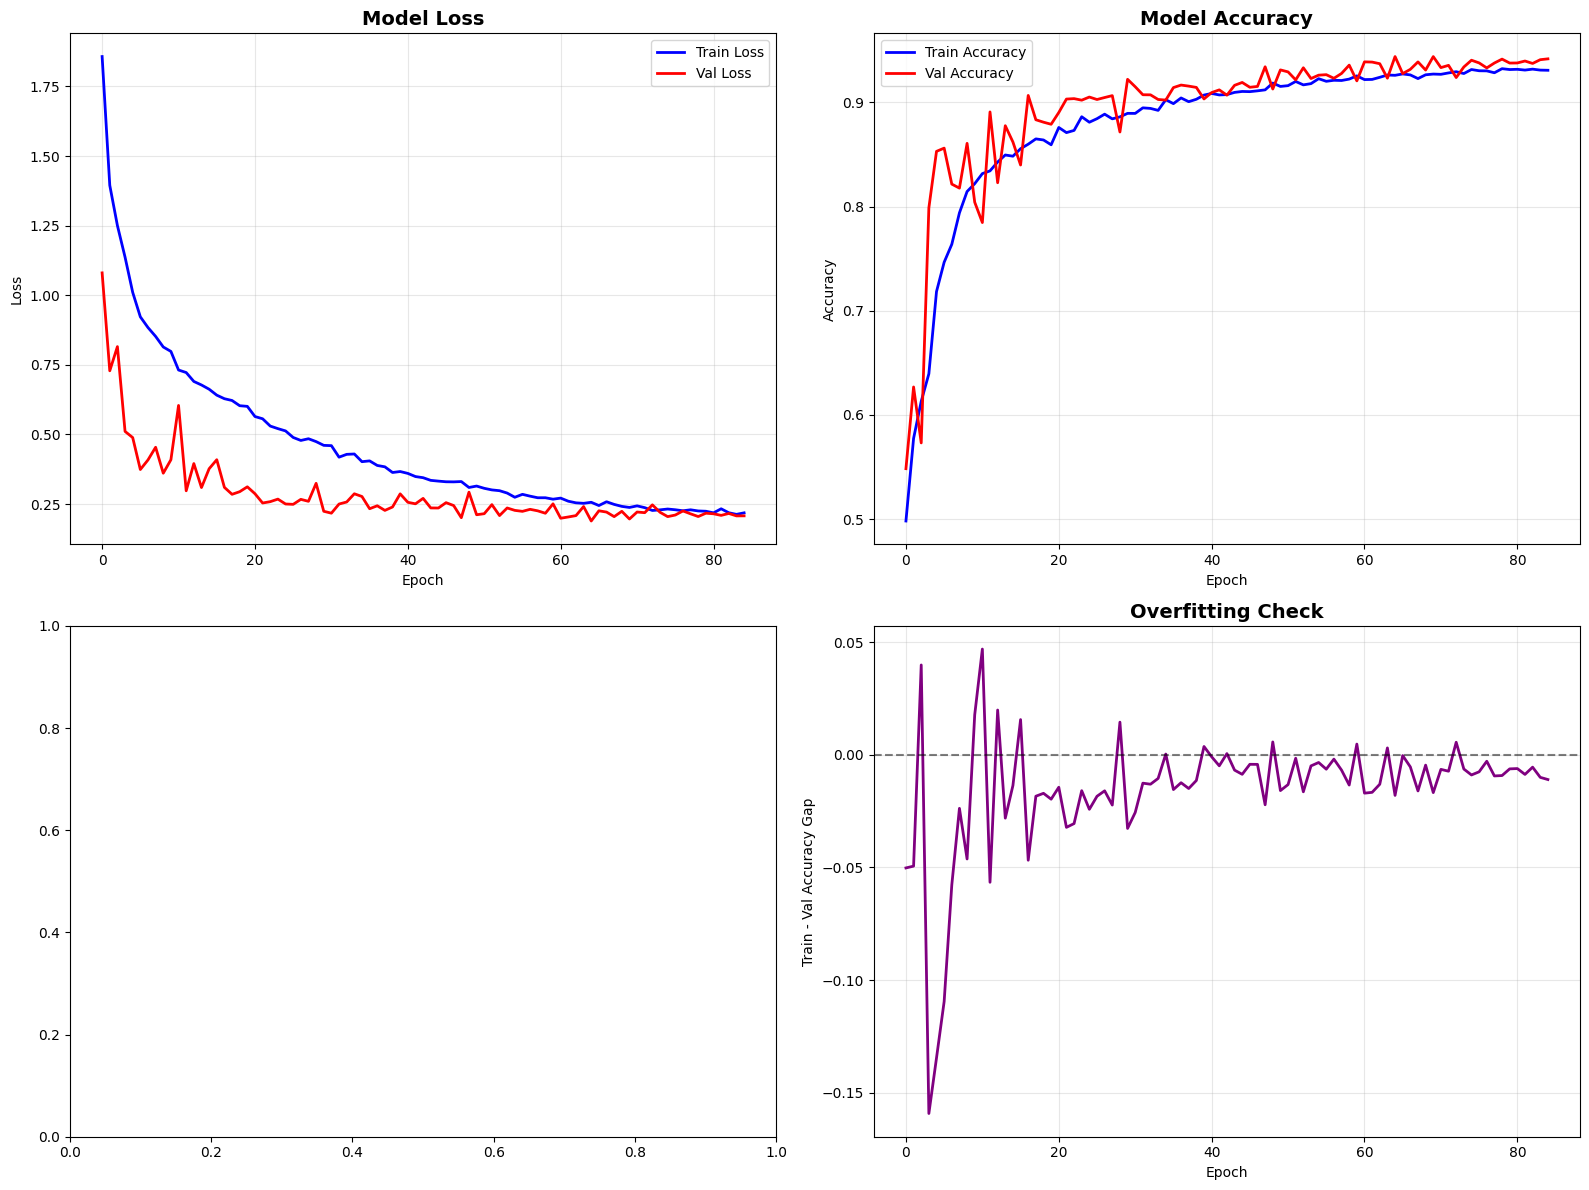


 Training history saved

EVALUATING ON TEST SET

 XGBoost results loaded for comparison

 PERFORMANCE METRICS:
Metric                         Train           Test            XGBoost        
--------------------------------------------------------------------------------
Accuracy                       0.9460          0.9515          0.9590
F1-Score (Macro)               0.7635          0.4842          0.4852
F1-Score (Weighted)            0.9554          0.9633          0.9659
Precision (Macro)              0.6962          0.4483
Recall (Macro)                 0.9180          0.6121

 CNN-LSTM did not beat XGBoost. Gap: -0.75%

 DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

         dig     0.1865    0.5714    0.2812        63
         eat     0.8089    0.8108    0.8099       872
       groom     0.1888    0.3994    0.2564       353
  head_shake     0.2353    0.8000    0.3636         5
      pounce     0.0000    0.0000    0.0000      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

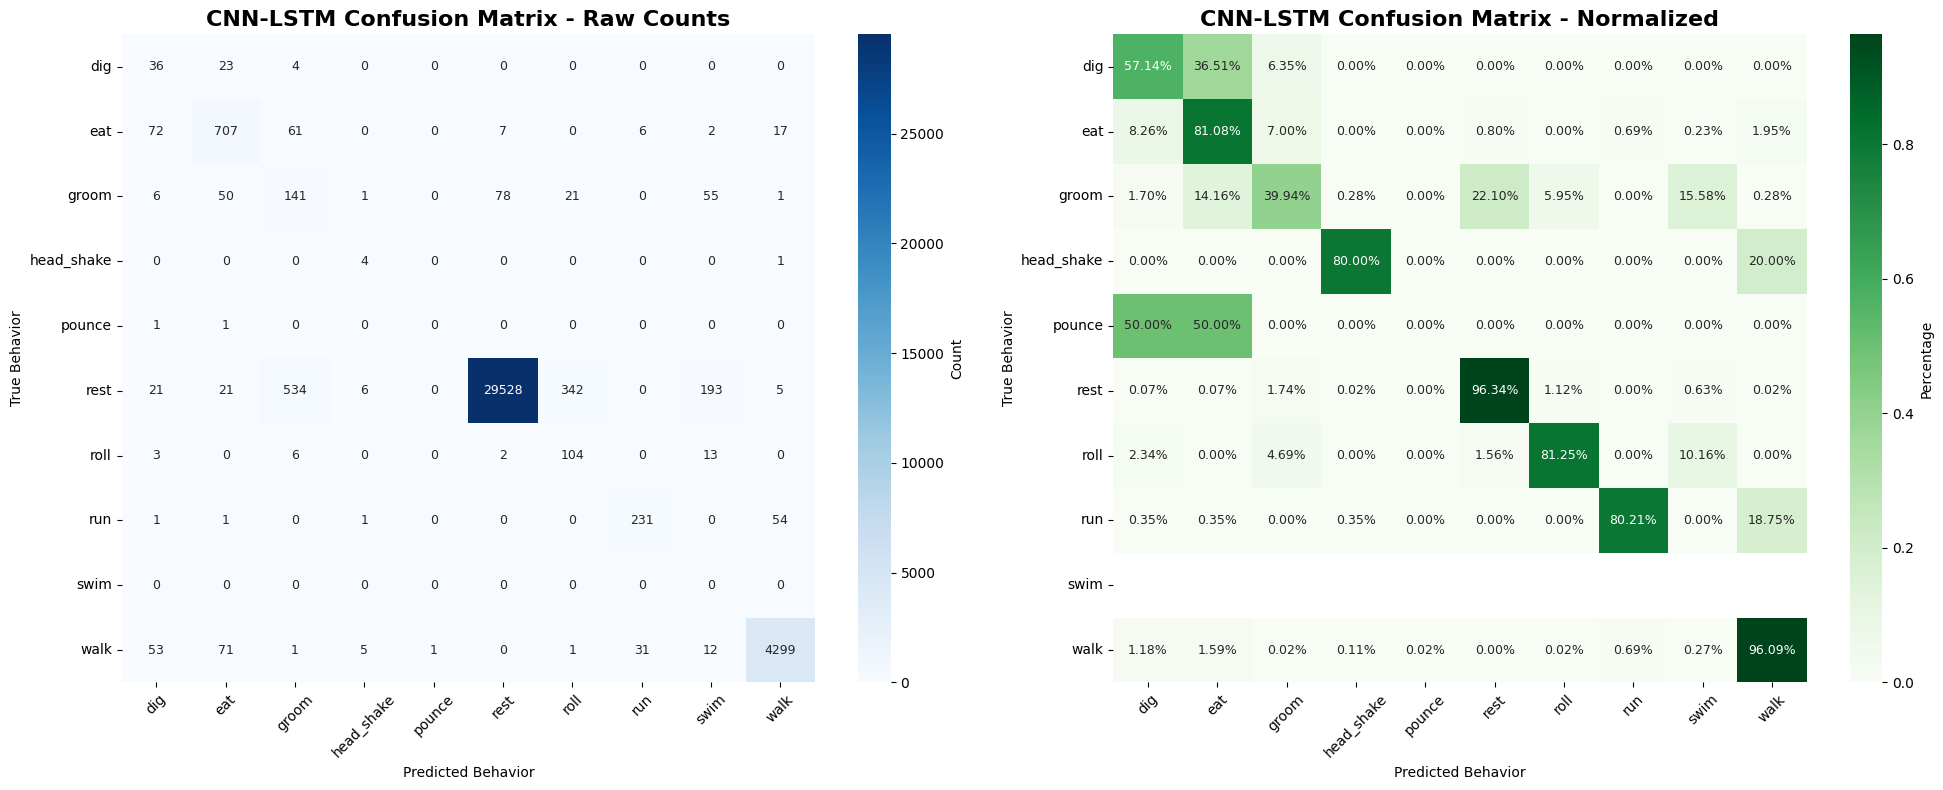


 Confusion matrix saved

 Top Confusion Pairs:
True Predicted  Count Percent
rest     groom    534    1.7%
rest      roll    342    1.1%
rest      swim    193    0.6%

 Per-Behavior Performance:
  Behavior  Samples  Precision   Recall  F1-Score
       dig       63   0.186528 0.571429  0.281250
       eat      872   0.808924 0.810780  0.809851
     groom      353   0.188755 0.399433  0.256364
head_shake        5   0.235294 0.800000  0.363636
    pounce        2   0.000000 0.000000  0.000000
      rest    30650   0.997062 0.963393  0.979939
      roll      128   0.222222 0.812500  0.348993
       run      288   0.861940 0.802083  0.830935
      swim        0   0.000000 0.000000  0.000000
      walk     4474   0.982180 0.960885  0.971416


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


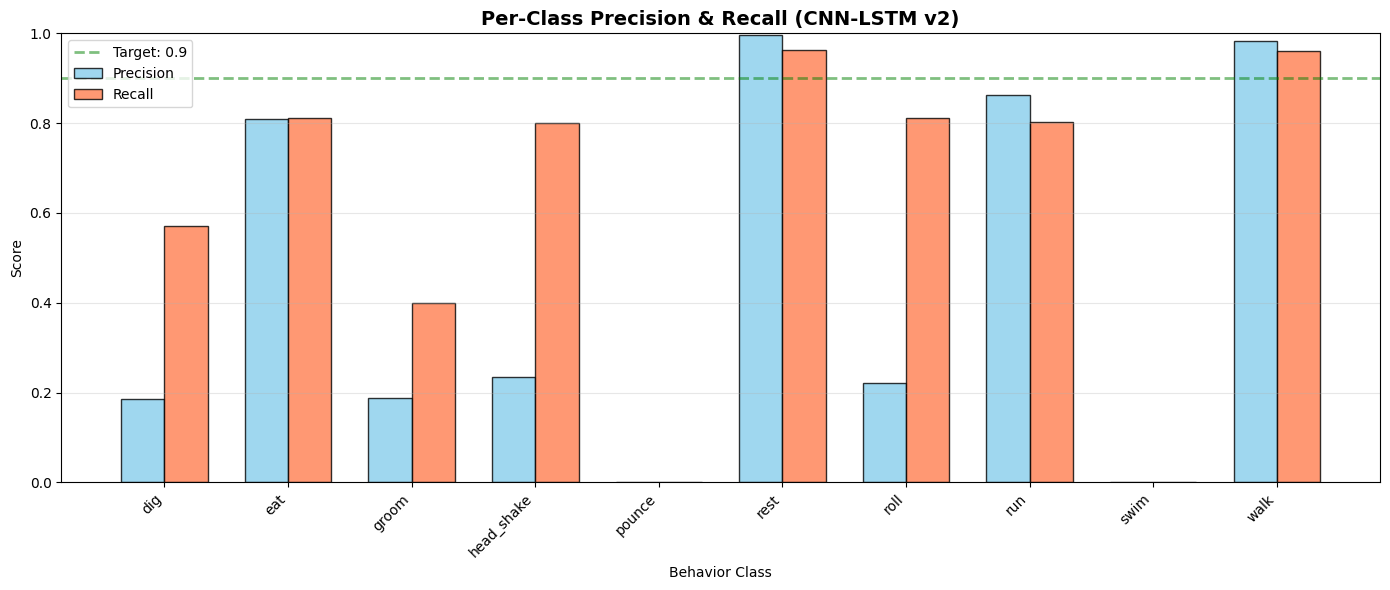


 All results saved!

 Final Test Accuracy : 0.9515 (95.15%)
 Final F1 (Macro)    : 0.4842

 vs XGBoost Accuracy : 0.9590 (-0.75%)
 vs XGBoost F1 Macro : 0.4852 (-0.0010)

 Ready for Week 3: SHAP Explainability!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import time
import json

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 80)
print("CNN-LSTM OPTIMIZED MODEL (V2) - WITH ALL FIXES")
print("=" * 80)

# ========================================================================
# STEP 1: LOAD DATA
# ========================================================================
print("\n Loading preprocessed data...")

DATA_PATH = '/kaggle/input/datasets/sruthi0304/bebe-bears-preprocessed-1'

X_train_raw = np.load(f'{DATA_PATH}/X_train_raw.npy')
X_test_raw  = np.load(f'{DATA_PATH}/X_test_raw.npy')
y_train     = np.load(f'{DATA_PATH}/y_train.npy')
y_test      = np.load(f'{DATA_PATH}/y_test.npy')

print(f"\n Data loaded!")
print(f"   Training : {X_train_raw.shape[0]:,} windows")
print(f"   Test     : {X_test_raw.shape[0]:,} windows")
print(f"   Window shape: ({X_train_raw.shape[1]} timesteps, {X_train_raw.shape[2]} axes)")

# ========================================================================
# STEP 2: REMAP LABELS TO CONSECUTIVE 0-INDEXED INTEGERS
# ========================================================================
# Keras requires class indices to be 0, 1, 2, ... N-1 consecutively.
# Some bear behavior classes may be missing from the train/test split
# (e.g. pounce=5 is very rare), so we remap to avoid index errors.

print("\n Remapping labels to consecutive integers...")
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print(f"   Original label values : {le.classes_}")
print(f"   Remapped to           : 0 – {len(le.classes_)-1}")

LABEL_NAMES = {
    1: 'dig', 2: 'eat', 3: 'groom', 4: 'head_shake',
    5: 'pounce', 6: 'rest', 7: 'roll', 8: 'run', 9: 'swim', 10: 'walk'
}

remapped_names = [LABEL_NAMES.get(c, str(c)) for c in le.classes_]
print(f"   Class names           : {remapped_names}")

# ========================================================================
# STEP 3: CALCULATE CLASS WEIGHTS
# ========================================================================
print("\n Computing class weights for imbalanced data...")

present_classes     = np.unique(y_train_encoded)
class_weights_array = compute_class_weight('balanced', classes=present_classes, y=y_train_encoded)
class_weights_dict  = {int(cls): float(w) for cls, w in zip(present_classes, class_weights_array)}

print("\n Class weights:")
for cls, weight in class_weights_dict.items():
    samples = np.sum(y_train_encoded == cls)
    name    = remapped_names[cls]
    print(f"  {cls} ({name:<12}): weight={weight:.3f}  ({samples:,} samples)")

num_classes     = len(present_classes)
input_timesteps = X_train_raw.shape[1]   # 32 for bears (2s × 16Hz)
input_axes      = X_train_raw.shape[2]   # 3  (AccX, AccY, AccZ)

print(f"\n Auto-detected: {num_classes} classes, input shape = ({input_timesteps}, {input_axes})")

# ========================================================================
# STEP 4: BUILD ENHANCED CNN-LSTM MODEL
# ========================================================================
print("\n" + "=" * 80)
print("BUILDING ENHANCED CNN-LSTM ARCHITECTURE")
print("=" * 80)

def create_enhanced_cnn_lstm(input_shape, num_classes):
    model = models.Sequential(name='Enhanced_CNN_LSTM')

    # CONV BLOCK 1
    model.add(layers.Conv1D(filters=128, kernel_size=7, activation='relu',
                             padding='same', input_shape=input_shape, name='conv1d_1a'))
    model.add(layers.BatchNormalization(name='bn_1a'))
    model.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu',
                             padding='same', name='conv1d_1b'))
    model.add(layers.BatchNormalization(name='bn_1b'))
    model.add(layers.MaxPooling1D(pool_size=2, name='pool_1'))
    model.add(layers.Dropout(0.3, name='dropout_1'))

    # CONV BLOCK 2
    model.add(layers.Conv1D(filters=256, kernel_size=5, activation='relu',
                             padding='same', name='conv1d_2a'))
    model.add(layers.BatchNormalization(name='bn_2a'))
    model.add(layers.Conv1D(filters=256, kernel_size=3, activation='relu',
                             padding='same', name='conv1d_2b'))
    model.add(layers.BatchNormalization(name='bn_2b'))
    model.add(layers.MaxPooling1D(pool_size=2, name='pool_2'))
    model.add(layers.Dropout(0.3, name='dropout_2'))

    # LSTM LAYERS
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True), name='bilstm_1'))
    model.add(layers.Dropout(0.4, name='dropout_3'))
    model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False), name='bilstm_2'))
    model.add(layers.Dropout(0.4, name='dropout_4'))

    # DENSE LAYERS
    model.add(layers.Dense(128, activation='relu', name='dense_1'))
    model.add(layers.BatchNormalization(name='bn_3'))
    model.add(layers.Dropout(0.5, name='dropout_5'))
    model.add(layers.Dense(64, activation='relu', name='dense_2'))
    model.add(layers.Dropout(0.4, name='dropout_6'))

    # OUTPUT
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

model = create_enhanced_cnn_lstm(
    input_shape=(input_timesteps, input_axes),
    num_classes=num_classes
)

print("\n Model Architecture Summary:")
model.summary()

total_params = model.count_params()
print(f"\n Total Parameters: {total_params:,}")

# ========================================================================
# STEP 5: COMPILE MODEL
# ========================================================================
print("\n" + "=" * 80)
print("COMPILING MODEL")
print("=" * 80)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n Model compiled!")
print("  - Optimizer    : Adam")
print("  - Learning Rate: 0.0005")
print("  - Loss         : Sparse Categorical Crossentropy")

# ========================================================================
# STEP 6: SETUP CALLBACKS
# ========================================================================
def lr_schedule(epoch):
    return max(0.0005 * (0.96 ** epoch), 1e-6)

callback_list = [
    callbacks.LearningRateScheduler(lr_schedule, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=20,
                            restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('cnn_lstm_best_model_v2.keras',
                               monitor='val_loss', save_best_only=True, verbose=1),
    callbacks.TensorBoard(log_dir='./logs', histogram_freq=0)
]

# ========================================================================
# STEP 7: TRAIN MODEL
# ========================================================================
print("\n" + "=" * 80)
print("TRAINING ENHANCED CNN-LSTM MODEL")
print("=" * 80)

BATCH_SIZE       = 64
EPOCHS           = 100
VALIDATION_SPLIT = 0.15

print(f"\n Training Configuration:")
print(f"  - Batch size      : {BATCH_SIZE}")
print(f"  - Max epochs      : {EPOCHS}")
print(f"  - Validation split: {VALIDATION_SPLIT*100:.0f}%")
print(f"  - Input shape     : ({input_timesteps}, {input_axes})")
print(f"  - Num classes     : {num_classes}")

start_time = time.time()

history = model.fit(
    X_train_raw, y_train_encoded,       # use encoded labels
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weights_dict,
    callbacks=callback_list,
    verbose=1
)

training_time = time.time() - start_time

print(f"\n Training completed in {training_time:.2f}s ({training_time/60:.2f} min)")
print(f" Epochs completed  : {len(history.history['loss'])}")
print(f" Best val_loss     : {min(history.history['val_loss']):.4f}")
print(f" Best val_accuracy : {max(history.history['val_accuracy']):.4f}")

# ========================================================================
# STEP 8: PLOT TRAINING HISTORY
# ========================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(history.history['loss'],     label='Train Loss',     linewidth=2, color='blue')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss',       linewidth=2, color='red')
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2, color='blue')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, color='red')
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

if 'lr' in history.history:
    axes[1, 0].plot(history.history['lr'], linewidth=2, color='green')
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_yscale('log'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(
    np.array(history.history['accuracy']) - np.array(history.history['val_accuracy']),
    linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Overfitting Check', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Train - Val Accuracy Gap')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_lstm_v2_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n Training history saved")

# ========================================================================
# STEP 9: EVALUATE ON TEST SET
# ========================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

y_train_pred_proba = model.predict(X_train_raw, batch_size=128, verbose=0)
y_train_pred_enc   = np.argmax(y_train_pred_proba, axis=1)

y_test_pred_proba  = model.predict(X_test_raw, batch_size=128, verbose=0)
y_test_pred_enc    = np.argmax(y_test_pred_proba, axis=1)

# Decode back to original label values for reporting
y_train_pred = le.inverse_transform(y_train_pred_enc)
y_test_pred  = le.inverse_transform(y_test_pred_enc)

train_accuracy    = accuracy_score(y_train, y_train_pred)
test_accuracy     = accuracy_score(y_test,  y_test_pred)
train_f1_macro    = f1_score(y_train, y_train_pred, average='macro')
test_f1_macro     = f1_score(y_test,  y_test_pred,  average='macro')
train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
test_f1_weighted  = f1_score(y_test,  y_test_pred,  average='weighted')

# Load XGBoost results for comparison
try:
    with open('xgboost_summary.json', 'r') as f:
        xgb_results = json.load(f)
    xgb_accuracy    = xgb_results['test_accuracy']
    xgb_f1_macro    = xgb_results['test_f1_macro']
    xgb_f1_weighted = xgb_results['test_f1_weighted']
    print(f"\n XGBoost results loaded for comparison")
except FileNotFoundError:
    xgb_accuracy = xgb_f1_macro = xgb_f1_weighted = None
    print("\n xgboost_summary.json not found — run Cells 17-24 first")

print("\n PERFORMANCE METRICS:")
print("=" * 80)
print(f"{'Metric':<30} {'Train':<15} {'Test':<15} {'XGBoost':<15}")
print("-" * 80)
xgb_acc_str = f"{xgb_accuracy:.4f}" if xgb_accuracy else "N/A"
xgb_f1m_str = f"{xgb_f1_macro:.4f}" if xgb_f1_macro else "N/A"
xgb_f1w_str = f"{xgb_f1_weighted:.4f}" if xgb_f1_weighted else "N/A"
print(f"{'Accuracy':<30} {train_accuracy:.4f}          {test_accuracy:.4f}          {xgb_acc_str}")
print(f"{'F1-Score (Macro)':<30} {train_f1_macro:.4f}          {test_f1_macro:.4f}          {xgb_f1m_str}")
print(f"{'F1-Score (Weighted)':<30} {train_f1_weighted:.4f}          {test_f1_weighted:.4f}          {xgb_f1w_str}")
print(f"{'Precision (Macro)':<30} {precision_score(y_train, y_train_pred, average='macro'):.4f}          {precision_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"{'Recall (Macro)':<30} {recall_score(y_train, y_train_pred, average='macro'):.4f}          {recall_score(y_test, y_test_pred, average='macro'):.4f}")
print("=" * 80)

if xgb_accuracy:
    if test_accuracy > xgb_accuracy:
        print(f"\n SUCCESS! CNN-LSTM beats XGBoost by {(test_accuracy - xgb_accuracy)*100:.2f}%!")
    else:
        print(f"\n CNN-LSTM did not beat XGBoost. Gap: {(test_accuracy - xgb_accuracy)*100:.2f}%")

print("\n DETAILED CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_test_pred,
                             target_names=[LABEL_NAMES.get(c, str(c)) for c in le.classes_],
                             digits=4))

# ========================================================================
# STEP 10: CONFUSION MATRIX
# ========================================================================
cm            = confusion_matrix(y_test, y_test_pred, labels=le.classes_)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
tick_labels   = [LABEL_NAMES.get(c, str(c)) for c in le.classes_]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 9})
axes[0].set_title('CNN-LSTM Confusion Matrix - Raw Counts', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Behavior'); axes[0].set_ylabel('True Behavior')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels,
            cbar_kws={'label': 'Percentage'}, annot_kws={'size': 9})
axes[1].set_title('CNN-LSTM Confusion Matrix - Normalized', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Predicted Behavior'); axes[1].set_ylabel('True Behavior')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('cnn_lstm_v2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n Confusion matrix saved")

# Top confusion pairs
confusion_pairs = []
for i, true_cls in enumerate(le.classes_):
    for j, pred_cls in enumerate(le.classes_):
        if i != j and cm[i, j] > 100:
            confusion_pairs.append({
                'True': LABEL_NAMES.get(true_cls, str(true_cls)),
                'Predicted': LABEL_NAMES.get(pred_cls, str(pred_cls)),
                'Count': cm[i, j],
                'Percent': f"{cm[i, j] / cm[i].sum() * 100:.1f}%"
            })
if confusion_pairs:
    print("\n Top Confusion Pairs:")
    print(pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False).head(10).to_string(index=False))

# ========================================================================
# STEP 11: PER-CLASS PERFORMANCE
# ========================================================================
per_class_f1        = f1_score(y_test, y_test_pred, average=None, labels=le.classes_)
per_class_precision = precision_score(y_test, y_test_pred, average=None, labels=le.classes_)
per_class_recall    = recall_score(y_test, y_test_pred, average=None, labels=le.classes_)

class_counts = pd.Series(y_test).value_counts().sort_index().reindex(le.classes_, fill_value=0)

performance_df = pd.DataFrame({
    'Behavior': tick_labels,
    'Samples':  class_counts.values,
    'Precision': per_class_precision,
    'Recall':    per_class_recall,
    'F1-Score':  per_class_f1
})
print("\n Per-Behavior Performance:")
print(performance_df.to_string(index=False))

x     = np.arange(len(le.classes_))
width = 0.35
plt.figure(figsize=(14, 6))
plt.bar(x - width/2, per_class_precision, width, label='Precision', alpha=0.8, color='skyblue', edgecolor='black')
plt.bar(x + width/2, per_class_recall,    width, label='Recall',    alpha=0.8, color='coral',   edgecolor='black')
plt.axhline(y=0.9, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 0.9')
plt.xlabel('Behavior Class'); plt.ylabel('Score')
plt.title('Per-Class Precision & Recall (CNN-LSTM v2)', fontsize=14, fontweight='bold')
plt.xticks(x, tick_labels, rotation=45, ha='right')
plt.ylim(0, 1.0); plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_lstm_v2_per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================================================
# STEP 12: SAVE ALL RESULTS
# ========================================================================
model.save('cnn_lstm_model_v2.keras')
np.save('cnn_lstm_v2_y_test_pred.npy',       y_test_pred)
np.save('cnn_lstm_v2_y_train_pred.npy',      y_train_pred)
np.save('cnn_lstm_v2_y_test_pred_proba.npy', y_test_pred_proba)
np.save('cnn_lstm_v2_confusion_matrix.npy',  cm)

cnn_lstm_results = {
    'model_name':            'CNN-LSTM-v2-Enhanced',
    'training_time_seconds': float(training_time),
    'total_epochs':          len(history.history['loss']),
    'best_epoch':            int(np.argmin(history.history['val_loss']) + 1),
    'test_accuracy':         float(test_accuracy),
    'test_f1_macro':         float(test_f1_macro),
    'test_f1_weighted':      float(test_f1_weighted),
    'test_precision_macro':  float(precision_score(y_test, y_test_pred, average='macro')),
    'test_recall_macro':     float(recall_score(y_test,  y_test_pred, average='macro')),
    'train_accuracy':        float(train_accuracy),
    'train_f1_macro':        float(train_f1_macro),
    'per_class_f1':          per_class_f1.tolist(),
    'per_class_precision':   per_class_precision.tolist(),
    'per_class_recall':      per_class_recall.tolist(),
    'total_parameters':      int(total_params),
    'batch_size':            BATCH_SIZE,
    'initial_learning_rate': 0.0005,
    'validation_split':      VALIDATION_SPLIT,
    'input_shape':           [input_timesteps, input_axes],
    'num_classes':           num_classes,
    'label_classes':         le.classes_.tolist()
}

with open('cnn_lstm_v2_results.json', 'w') as f:
    json.dump(cnn_lstm_results, f, indent=2)

performance_df.to_csv('cnn_lstm_v2_per_class_performance.csv', index=False)
pd.DataFrame(history.history).to_csv('cnn_lstm_v2_training_history.csv', index=False)

print("\n All results saved!")
print(f"\n Final Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f" Final F1 (Macro)    : {test_f1_macro:.4f}")
if xgb_accuracy:
    print(f"\n vs XGBoost Accuracy : {xgb_accuracy:.4f} ({(test_accuracy-xgb_accuracy)*100:+.2f}%)")
    print(f" vs XGBoost F1 Macro : {xgb_f1_macro:.4f} ({(test_f1_macro-xgb_f1_macro):+.4f})")
print("\n Ready for Week 3: SHAP Explainability!")

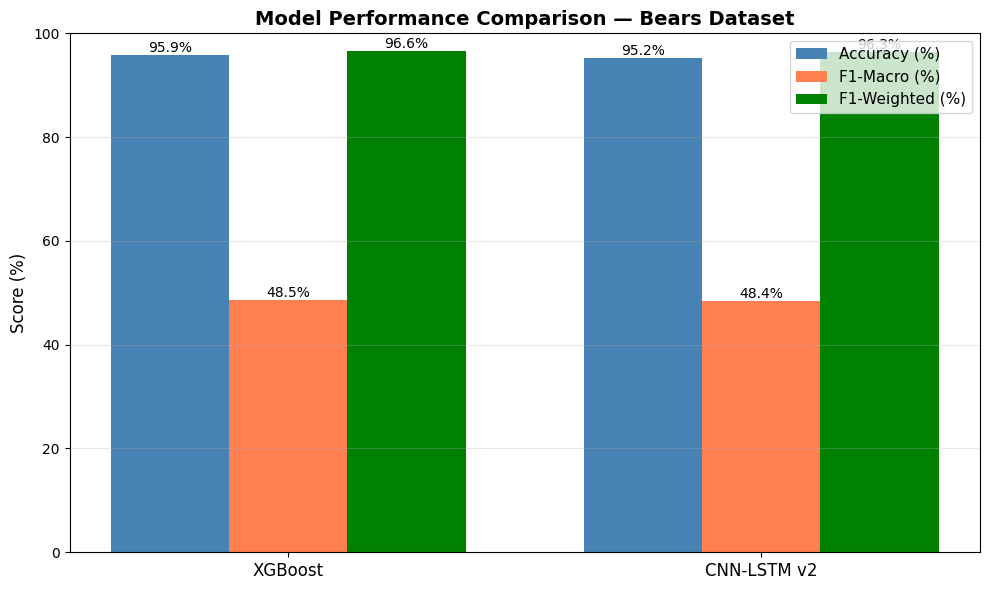

In [25]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('xgboost_summary.json', 'r') as f:
    xgb_res = json.load(f)
with open('cnn_lstm_v2_results.json', 'r') as f:
    cnn_res = json.load(f)

models_list = ['XGBoost', 'CNN-LSTM v2']
accuracy    = [xgb_res['test_accuracy']*100,    cnn_res['test_accuracy']*100]
f1_macro    = [xgb_res['test_f1_macro']*100,    cnn_res['test_f1_macro']*100]
f1_weighted = [xgb_res['test_f1_weighted']*100, cnn_res['test_f1_weighted']*100]

x = np.arange(len(models_list))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, accuracy,    width, label='Accuracy (%)',    color='steelblue')
bars2 = ax.bar(x,         f1_macro,    width, label='F1-Macro (%)',    color='coral')
bars3 = ax.bar(x + width, f1_weighted, width, label='F1-Weighted (%)', color='green')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison — Bears Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300)
plt.show() 

WEEK 3: SHAP EXPLAINABILITY ANALYSIS

 Loading preprocessed data and models...

 Data loaded!
   Training features : (157190, 35)
   Test features     : (36835, 35)

 XGBoost model loaded!
 Label encoder loaded!
 Predictions loaded!
 Model results loaded!

 XGBoost  — Accuracy: 0.9590 | F1: 0.4852
 CNN-LSTM — Accuracy: 0.9515 | F1: 0.4842


 Computing SHAP values (this may take a few minutes)...


/tmp/ipykernel_55/1144972621.py:65: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample,
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: Future

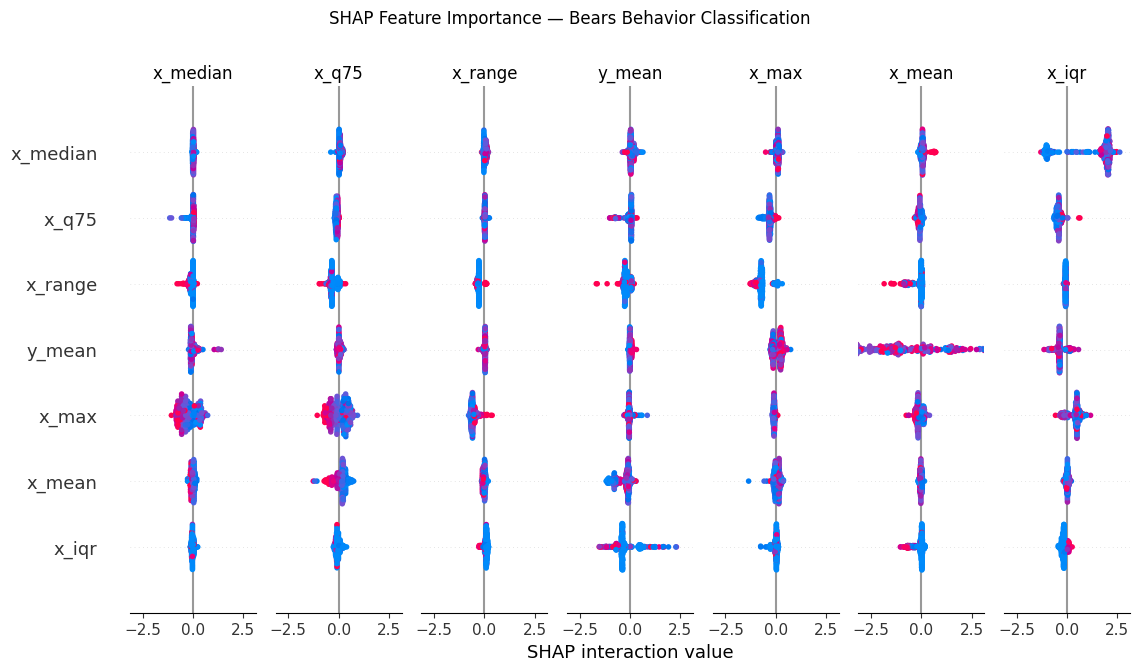

/tmp/ipykernel_55/1144972621.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample,


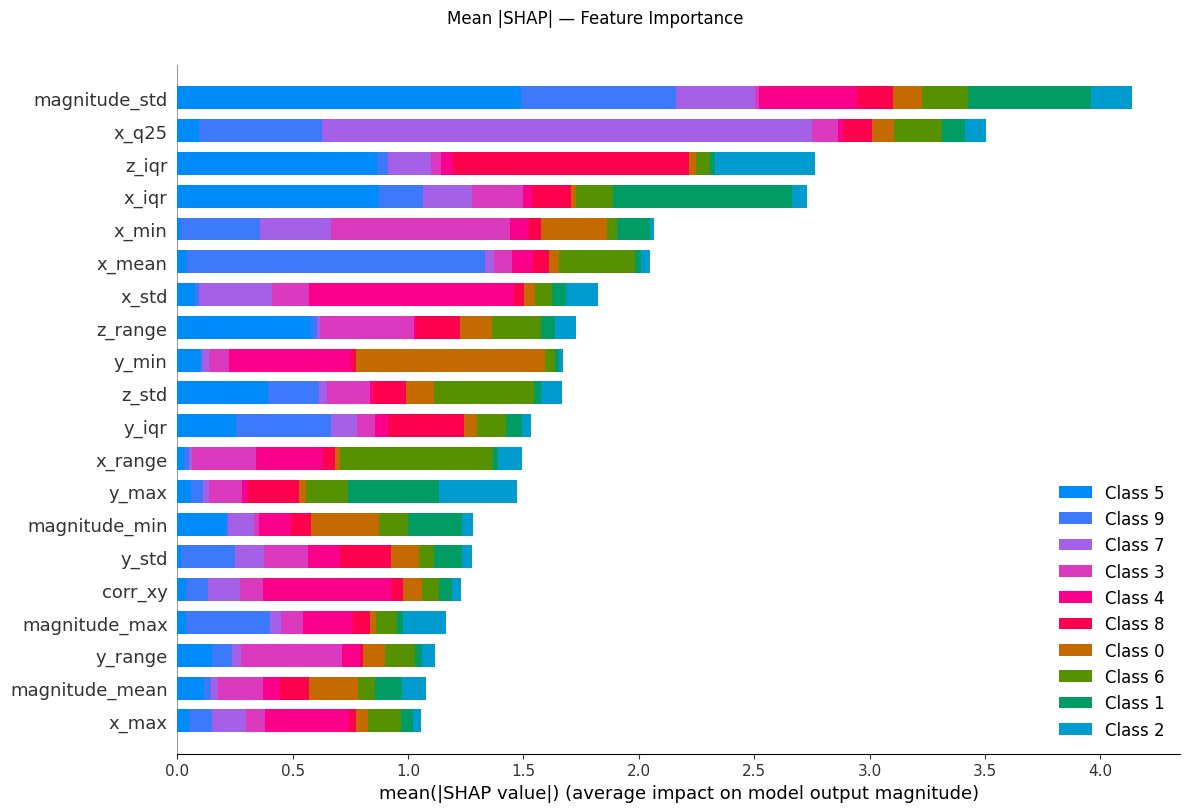


 SHAP analysis complete! Files saved:
  - shap_summary_plot.png
  - shap_bar_plot.png


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import json
import pickle
from sklearn.metrics import confusion_matrix, classification_report

shap.initjs()

print("=" * 80)
print("WEEK 3: SHAP EXPLAINABILITY ANALYSIS")
print("=" * 80)

print("\n Loading preprocessed data and models...")

DATA_PATH = '/kaggle/input/datasets/sruthi0304/bebe-bears-preprocessed-1'

X_train = pd.read_csv(f'{DATA_PATH}/X_train_features.csv')
X_test  = pd.read_csv(f'{DATA_PATH}/X_test_features.csv')
y_train = pd.read_csv(f'{DATA_PATH}/y_train.csv')['behavior_label'].values
y_test  = pd.read_csv(f'{DATA_PATH}/y_test.csv')['behavior_label'].values

print(f"\n Data loaded!")
print(f"   Training features : {X_train.shape}")
print(f"   Test features     : {X_test.shape}")

# Load XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('xgboost_model.json')
print(f"\n XGBoost model loaded!")

# Load label encoder and decode predictions back to original labels (1-10)
with open('xgb_label_encoder.pkl', 'rb') as f:
    le_xgb = pickle.load(f)
print(f" Label encoder loaded!")

# Load predictions (already decoded to original labels)
y_test_pred_xgb = np.load('xgboost_y_test_pred.npy')
y_test_pred_cnn = np.load('cnn_lstm_v2_y_test_pred.npy')
print(f" Predictions loaded!")

with open('xgboost_summary.json', 'r') as f:
    xgb_results = json.load(f)
with open('cnn_lstm_v2_results.json', 'r') as f:
    cnn_results = json.load(f)

print(f" Model results loaded!")
print(f"\n XGBoost  — Accuracy: {xgb_results['test_accuracy']:.4f} | F1: {xgb_results['test_f1_macro']:.4f}")
print(f" CNN-LSTM — Accuracy: {cnn_results['test_accuracy']:.4f} | F1: {cnn_results['test_f1_macro']:.4f}")
print("\n" + "=" * 80)

# ========================================================================
# SHAP ANALYSIS
# ========================================================================
print("\n Computing SHAP values (this may take a few minutes)...")

X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample,
                  feature_names=X_train.columns.tolist(),
                  show=False, plot_size=(12, 8))
plt.suptitle("SHAP Feature Importance — Bears Behavior Classification", y=1.01)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

shap.summary_plot(shap_values, X_sample,
                  feature_names=X_train.columns.tolist(),
                  plot_type='bar', show=False, plot_size=(12, 8))
plt.suptitle("Mean |SHAP| — Feature Importance", y=1.01)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n SHAP analysis complete! Files saved:")
print("  - shap_summary_plot.png")
print("  - shap_bar_plot.png")